# Final Project

Iris DeGutis

In [1]:
import numpy as np
import sep

The final project asks you to analyze and assess the statistical significance of events in scientific data relative to a model. You will do this by following tutorials developed for a nearly identical problem, so that your main task will be to carefully read through these tutorials, copy the parts that you need and modify some code to customize it for your own project.

You will create a Jupyter notebook for this project and, when finished, you will upload your notebook to GitHub and submit the URL to it as the submission to the assignment.

Before you begin
Create a new notebook in your working directory. Copy these instructions as plain text into the first cell. That way you will not have to flip back and forth between your notebook and this page.
Make sure that the astropy and sep packages are installed on your machine:
pip install astropy
pip install sep
Download the file hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits from this archiveLinks to an external site. and save it to your working directory (the same directory that has your notebook).
The task
Follow the tutorial found at https://sep.readthedocs.io/en/stable/tutorial.htmlLinks to an external site., applying it to the data file you just downloaded. For best results (and for full credit) follow these suggestions: 

Gradually copy the code from the tutorial into your own jupyter notebook, run and debug until you successfully replicate the tutorial. Do not try to copy and run it all at once, it's not going to work! You need to debug as you go.
Use markdown to break the notebook into sections, as in the tutorial.
Finish your notebook by answering the following questions, using a combination of text and code directly in the notebook. (Terms like sources and fluxes will gradually become clear as you progress through the tutorial. You are not expected to fully understand all the details.) 
1) How many sources (stars) do you find in the data? Histogram their fluxes.
2) What are the mean, median, and standard deviation of the distribution of fluxes.
3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

Final thoughts

This project should take a few hours to complete. You WILL run into various issues. Some of them I can predict already (but I won't tell you, yet) and some will be a surprise for everyone. Keep in mind: this is NOT a closed-book exam. You are allowed to ask for help. You may find it more efficient to begin troubleshooting by yourself, using a combination of reading error messages, looking through examples from lecture, searching online, etc. But as soon as you feel thoroughly stuck, ask for help.
The due date on Canvas is designed to drive you into action, with the goal of getting this project out of the way so you can focus on studying for finals. However, we will accept late submissions

In [2]:
import astropy.io.fits
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [3]:
filename = 'hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits'
data = fits.getdata(filename)

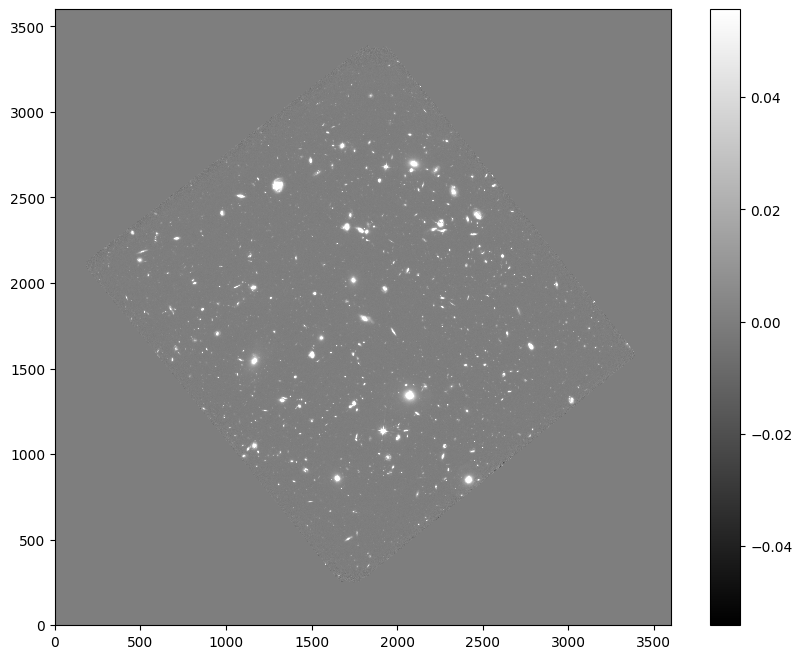

In [4]:
# show the image
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

In [8]:
# measure a spatially varying background on the image
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data)

In [9]:
# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [10]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equivalent to above

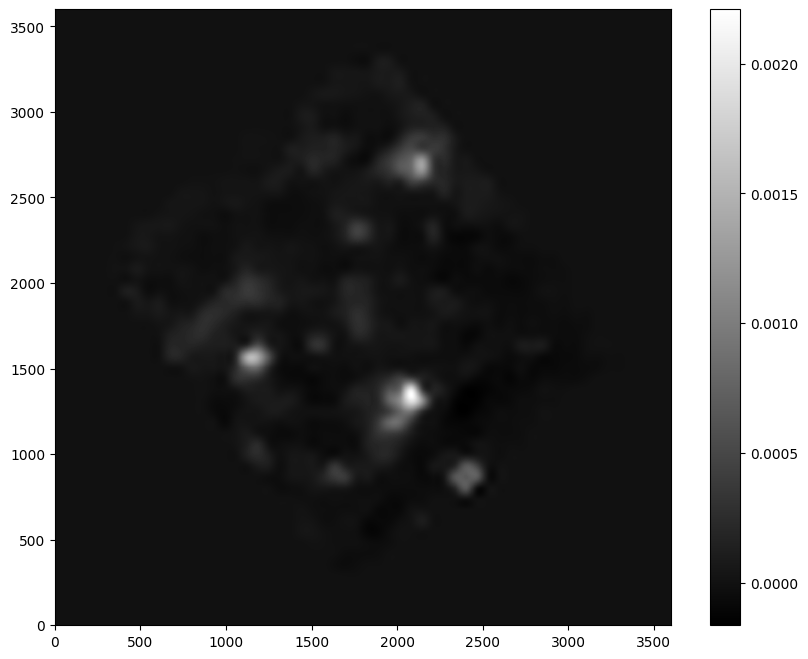

In [11]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [12]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

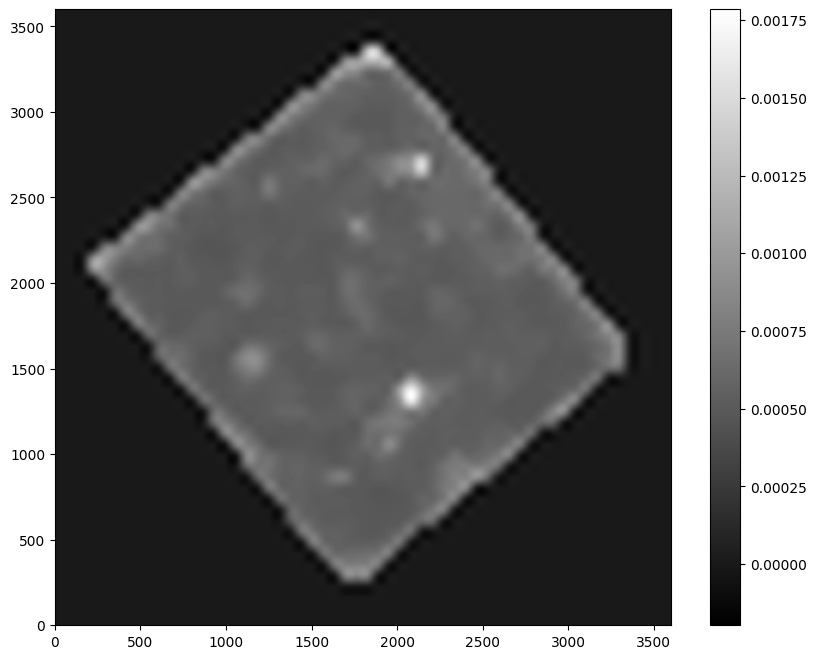

In [13]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [19]:
# subtract the background
data_sub = data - bkg

In [20]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

In [21]:
# how many objects were detected
len(objects)

8629

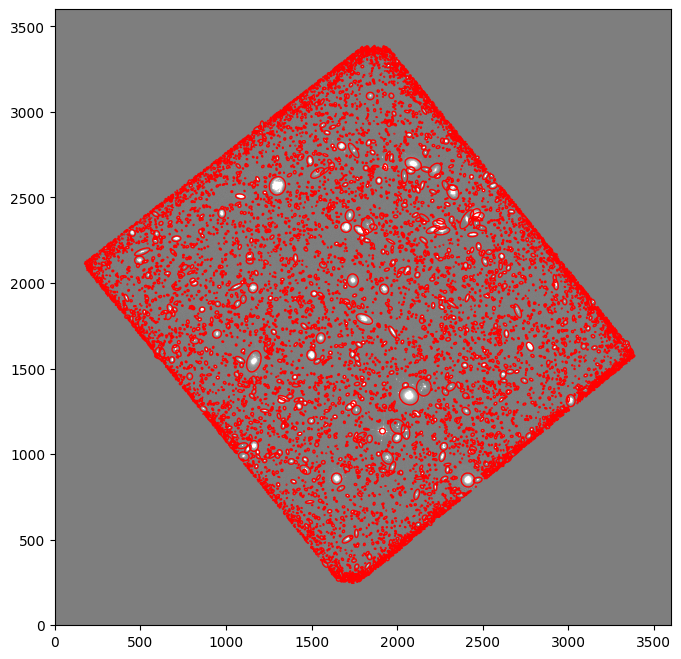

In [22]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [23]:
# available fields
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

In [24]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [38]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.031282 +/- 0.176890
object 1: flux = 0.031018 +/- 0.176142
object 2: flux = -0.024388 +/- 0.002883
object 3: flux = 0.001947 +/- 0.044219
object 4: flux = 0.012457 +/- 0.111649
object 5: flux = -0.011228 +/- 0.002875
object 6: flux = 0.029368 +/- 0.171394
object 7: flux = -0.009126 +/- 0.002875
object 8: flux = 0.048023 +/- 0.219161
object 9: flux = 0.027840 +/- 0.166877


1. How many sources (stars) do you find in the data? Histogram their fluxes. I found 8629 stars

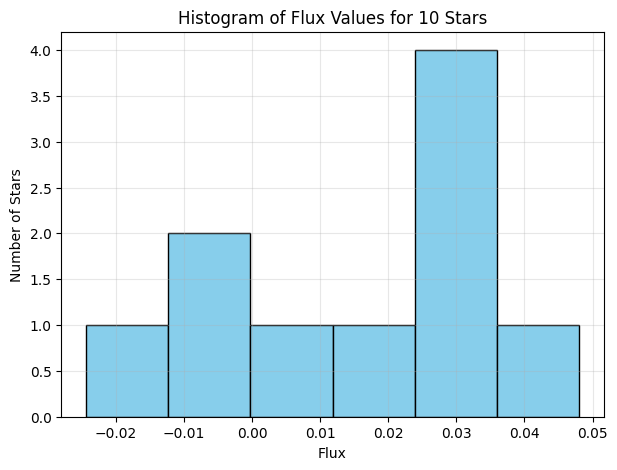

In [39]:
import matplotlib.pyplot as plt

flux = [
    0.031282,
    0.031018,
    -0.024388,
    0.001947,
    0.012457,
    -0.011228,
    0.029368,
    -0.009126,
    0.048023,
    0.027840
]

plt.figure(figsize=(7,5))
plt.hist(flux, bins=6, edgecolor='black', color='skyblue')
plt.xlabel("Flux")
plt.ylabel("Number of Stars")
plt.title("Histogram of Flux Values for 10 Stars")
plt.grid(alpha=0.3)

plt.show()

2. What are the mean, median, and standard deviation of the distribution of fluxes.

In [45]:
import numpy as np

flux = np.array([
    0.031282,
    0.031018,
    -0.024388,
    0.001947,
    0.012457,
    -0.011228,
    0.029368,
    -0.009126,
    0.048023,
    0.027840
])

mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux, ddof=1)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Standard deviation:", std_flux)

Mean flux: 0.013719299999999999
Median flux: 0.0201485
Standard deviation: 0.023488379013413798


3. What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

In [50]:
import numpy as np

flux = np.array([
    0.031282,
    0.031018,
    -0.024388,
    0.001947,
    0.012457,
    -0.011228,
    0.029368,
    -0.009126,
    0.048023,
    0.027840
])

mean_flux = np.mean(flux)
std_flux = np.std(flux, ddof=1)

z_scores = (flux - mean_flux) / std_flux

max_outlier_index = np.argmax(np.abs(z_scores))
max_outlier_value = flux[max_outlier_index]
max_outlier_z = z_scores[max_outlier_index]

print("Mean flux:", mean_flux)
print("Standard deviation:", std_flux)
print("Largest outlier flux:", max_outlier_value)
print("Index of outlier:", max_outlier_index)
print("Number of standard deviations from mean:", max_outlier_z)

Mean flux: 0.013719299999999999
Standard deviation: 0.023488379013413798
Largest outlier flux: -0.024388
Index of outlier: 2
Number of standard deviations from mean: -1.6223895219945825
